# Notebook to generate star list for pointing/alignment data
Author: Zach Curtis-Ginsberg
Updated: June 3rd, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_body, get_sun
from astropy.time import Time
from astropy.visualization import quantity_support
import pandas as pd
from tqdm import tqdm, trange
from astroquery.simbad import Simbad
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline, PchipInterpolator, make_splrep
import time

In [2]:
# Load site information
psct = EarthLocation(lat=31.674761*u.deg,lon=-110.952795*u.deg,height=1271*u.m)
utcoffset = -7 * u.hour
date = Time(time.time(), format='unix').iso

# If the time is greater than noon UTC, go to the next day Arizona midnight, else today Arizona midnight
if int(date[11:13]) > 12:
    day = int(date[8:10]) + 1
    date = Time(f'{date[:8]}{day} 07:00:00.00')
else:
    date = Time(f'{date[:10]} 07:00:00.00')

In [3]:
# Get list of stars with a certain (V band) magnitude
# This can take a long time if the database is not cached
simbad = Simbad()
simbad.add_votable_fields("V")
stars = simbad.query_catalog("HR", criteria="V<=4.5") # if you want it to be within certain values can do something like criteria="4.0<=V AND V<=4.5"

star_sources = []
star_mags = []
star_az_alts = []
for n, star in tqdm(enumerate(stars), total=len(stars)):
    _source = SkyCoord.from_name(star['main_id'])
    altaz = _source.transform_to(AltAz(obstime=date, location=psct))
    _alt = altaz.alt.value
    _az = altaz.az.value
    if _alt < 45:
        continue
    star_sources.append(_source)
    star_mags.append(star['V'])
    star_az_alts.append((_az, _alt))
star_alt_az = np.array(star_az_alts)

100%|██████████| 894/894 [00:03<00:00, 280.66it/s]


In [27]:
num_azs = 10
num_alts = 5

grid = []
azs = np.linspace(0, 360, num_azs, endpoint=False)
alts = np.linspace(45, 85, num_alts, endpoint=True)
for n, az in enumerate(azs):
    for m, alt in enumerate(alts):
        grid.append((az, alt))
grid = np.array(grid)

grid_stars = []
grid_az_alts = []
grid_mags = []

for grid_loc in grid:
    distances = np.linalg.norm(star_az_alts-grid_loc, axis=1) 
    min_index = np.argmin(distances)
    if stars[min_index] in grid_stars:
        continue
    grid_stars.append(stars[min_index])
    grid_az_alts.append(star_az_alts[min_index])
    grid_mags.append(star_mags[min_index])

In [43]:
a = SkyCoord.from_name('* bet Aur')

In [51]:
a.dec

<Latitude 44.94743257 deg>

In [55]:
for n, star, az_alt, mag in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags):
    _name = star['main_id']
    _src = SkyCoord.from_name(_name)
    _ra = _src.ra
    _dec = _src.dec
    #print(f'{_name}: {_ra:.2f}° RA, {_dec:.2f}° Dec')
    print(f'{_name}:', _ra, 'RA,', _dec, 'Dec')

* bet Aur: 89d52m55.843932s RA, 44d56m50.757252s Dec
* eps Ori: 84d03m12.200184s RA, -1d12m06.908904s Dec
* gam Cas: 14d10m37.966404s RA, 60d43m00.264072s Dec
* alf And: 2d05m48.898284s RA, 29d05m25.552032s Dec
* alf CMi: 114d49m31.792476s RA, 5d13m29.955216s Dec
* alf Oph: 263d44m01.041792s RA, 12d33m36.134604s Dec
* eps Car: 125d37m42.528864s RA, -59d30m34.143084s Dec
* zet01 UMa: 200d58m53.134212s RA, 54d55m31.295568s Dec
* gam UMa: 178d27m27.70974s RA, 53d41m41.135028s Dec
* eps Boo: 221d14m48.263388s RA, 27d04m27.200352s Dec
* lam Vel: 136d59m56.368104s RA, -43d25m57.327276s Dec
* bet Car: 138d17m59.661888s RA, -69d43m01.94736s Dec
* eps CMa: 104d39m23.23134s RA, -28d58m19.510176s Dec
* kap Vel: 140d31m42.264156s RA, -55d00m38.401668s Dec
* alf Cep: 319d38m41.58492s RA, 62d35m08.068056s Dec
* zet Cen: 208d53m05.78472s RA, -47d17m18.148236s Dec
* alf Per: 51d04m50.551392s RA, 49d51m40.245444s Dec
* tet Cen: 211d40m14.212848s RA, -36d22m11.837064s Dec
* gam02 Vel: 122d22m59.252016s 

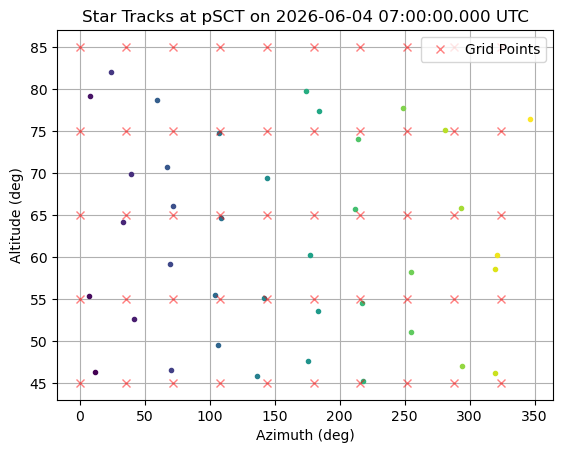

In [56]:
cmap = plt.get_cmap('viridis', len(grid_stars))
for n, star, az_alt, mag in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags):
    az, alt = az_alt
    plt.plot(az, alt, '.', color=cmap(n))#, label=f'{star['main_id']} V {mag:.2f}')
for grid_point in grid:
    grid_az, grid_alt = grid_point
    plt.plot(grid_az, grid_alt, 'x', color='r', alpha=0.5)
plt.plot([], [], 'x', color='r', label='Grid Points', alpha=0.5)
#plt.legend(bbox_to_anchor=(1,1), ncols=2)
plt.legend()
plt.xlabel('Azimuth (deg)')
plt.ylabel('Altitude (deg)')
plt.title(f'Star Tracks at pSCT on {date} UTC')
plt.grid(which='both')
plt.show()